<a href="https://colab.research.google.com/github/dsShekila/Engage-course-project/blob/main/Throat_cancer_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import scipy.stats as stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Reading data
data=pd.read_excel("/content/drive/MyDrive/engage2/Nyeriproject/GutCancer.xlsx")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525 entries, 0 to 524
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Incident date   525 non-null    object
 1   Age in years    525 non-null    object
 2   Sex             525 non-null    object
 3   Primary Site    525 non-null    object
 4   Patient status  525 non-null    object
 5   TNM Staging     334 non-null    object
dtypes: object(6)
memory usage: 24.7+ KB


In [ ]:
print(f"Shape: {data.shape}")
print(f"\nData Types:\n{data.dtypes}")
print(f"\nMissing Values:\n{data.isnull().sum()}")
print(f"\nKey Stats:\n{data.describe()}")

Shape: (525, 6)

Data Types:
Incident date     object
Age in years      object
Sex               object
Primary Site      object
Patient status    object
TNM Staging       object
dtype: object

Missing Values:
Incident date       0
Age in years        0
Sex                 0
Primary Site        0
Patient status      0
TNM Staging       191
dtype: int64

Key Stats:
                Incident date Age in years   Sex   Primary Site  \
count                     525          525   525            525   
unique                    492            5     2              7   
top     2025-06-18 00:00:00.0         70 +  Male  Esophagus NOS   
freq                        5          222   355            455   

       Patient status TNM Staging  
count             525         334  
unique              2           5  
top             Alive    Stage IV  
freq              284         250  


In [ ]:
# Create a copy for cleaning
df_clean = data.copy()

# 2.1 Parse Incident Date and derive Month/Year
df_clean['Incident_date'] = pd.to_datetime(df_clean['Incident date'])
df_clean['Incident_month'] = df_clean['Incident_date'].dt.month
df_clean['Incident_year'] = df_clean['Incident_date'].dt.year
df_clean['Incident_quarter'] = df_clean['Incident_date'].dt.quarter

# 2.2 Standardize Age bands and create AgeMid
def get_age_mid(age_band):
    if pd.isna(age_band):
        return np.nan
    if '70 +' in age_band:
        return 75  # Using 75 as midpoint for 70+
    elif '-' in age_band:
        ages = age_band.split(' - ')[0].split(' ')[0]
        start_age = int(ages)
        return start_age + 4.5  # Midpoint of the range
    return np.nan

df_clean['AgeMid'] = df_clean['Age in years'].apply(get_age_mid)
df_clean['AgeBand'] = df_clean['Age in years']  # Keep original for categorical analysis

# 2.3 Normalize Sex
df_clean['Sex'] = df_clean['Sex'].str.strip().str.title()
print("\nUnique Sex values:", df_clean['Sex'].unique())

# 2.4 Normalize Primary Site
df_clean['Primary Site'] = df_clean['Primary Site'].str.strip()
primary_site_mapping = {
    'Esophagus NOS': 'Esophagus NOS',
    'Overlapping lesion of esophagus': 'Overlapping Lesion',
    'Esophagus lower third': 'Lower Third',
    'Cervical esophagus': 'Cervical',
    'Abdominal esophagus': 'Abdominal',
    'Middle third of esophagus': 'Middle Third',
    'Upper third of esophagus': 'Upper Third'
}

df_clean['PrimarySite_Normalized'] = df_clean['Primary Site'].map(primary_site_mapping)
df_clean['PrimarySite_Normalized'] = df_clean['PrimarySite_Normalized'].fillna('Other')

# 2.5 Normalize Patient Status and TNM Staging
df_clean['Patient_status'] = df_clean['Patient status'].str.strip().str.title()
df_clean['TNM_Stage'] = df_clean['TNM Staging'].str.strip()

# Create ordered categories for TNM Stage
stage_order = ['Stage I', 'Stage II', 'Stage III', 'Stage IV', 'Unstaged']
df_clean['TNM_Stage_Ordered'] = pd.Categorical(
    df_clean['TNM_Stage'],
    categories=stage_order,
    ordered=True
)

# Create numeric stage for analysis
stage_numeric = {'Stage I': 1, 'Stage II': 2, 'Stage III': 3, 'Stage IV': 4, 'Unstaged': np.nan}
df_clean['Stage_Numeric'] = df_clean['TNM_Stage'].map(stage_numeric)

print("\nData after cleaning:")
print(df_clean[['Age in years', 'AgeMid', 'Sex', 'PrimarySite_Normalized', 'TNM_Stage']].head())


Unique Sex values: ['Male' 'Female']

Data after cleaning:
    Age in years  AgeMid     Sex PrimarySite_Normalized TNM_Stage
0           70 +    75.0    Male     Overlapping Lesion       NaN
1           70 +    75.0    Male          Esophagus NOS  Unstaged
2  50 - 59 years    54.5  Female          Esophagus NOS       NaN
3           70 +    75.0    Male          Esophagus NOS  Stage IV
4           70 +    75.0    Male          Esophagus NOS       NaN


In [ ]:
df_clean.dropna(inplace=True)

In [ ]:
df_clean.isnull().sum()

,0
Incident date,0
Age in years,0
Sex,0
Primary Site,0
Patient status,0
TNM Staging,0
Incident_date,0
Incident_month,0
Incident_year,0
Incident_quarter,0


In [ ]:
# Create derived variables
df_clean['LateStage'] = df_clean['TNM_Stage'].isin(['Stage III', 'Stage IV'])
df_clean['Unstaged_Flag'] = df_clean['TNM_Stage'] == 'Unstaged'
df_clean['Sex_Male'] = (df_clean['Sex'] == 'Male').astype(int)
df_clean['Patient_Dead'] = (df_clean['Patient_status'] == 'Dead').astype(int)

print("\nDerived indicators created:")
print("LateStage:", df_clean['LateStage'].mean())
print("Unstaged:", df_clean['Unstaged_Flag'].mean())
print("Male:", df_clean['Sex_Male'].mean())
print("Dead:", df_clean['Patient_Dead'].mean())


Derived indicators created:
LateStage: 0.9314641744548287
Unstaged: 0.0
Male: 0.67601246105919
Dead: 0.5420560747663551


The proportion of patients with Late Stage cancer.
The proportion of patients with Unstaged cancer.
The proportion of male patients.
The proportion of patients who are deceased.

In [ ]:
# TNM Stage Distribution
print("=== TNM STAGE DISTRIBUTION ===")
stage_dist = df_clean['TNM_Stage'].value_counts(normalize=True) * 100
print(stage_dist)

print(f"\nLate Stage (III-IV): {df_clean['LateStage'].mean()*100:.1f}%")
print(f"Unstaged: {df_clean['Unstaged_Flag'].mean()*100:.1f}%")

# 5.2 Patient Status by Stage
print("\n=== PATIENT STATUS BY STAGE ===")
status_by_stage = pd.crosstab(df_clean['TNM_Stage'], df_clean['Patient_status'], normalize='index') * 100
print(status_by_stage)

# 5.3 Sex Distribution
print("\n=== SEX DISTRIBUTION ===")
sex_dist = df_clean['Sex'].value_counts(normalize=True) * 100
print(sex_dist)

# Sex by Stage
print("\n=== SEX DISTRIBUTION BY STAGE ===")
sex_by_stage = pd.crosstab(df_clean['TNM_Stage'], df_clean['Sex'], normalize='index') * 100
print(sex_by_stage)

# 5.4 Age Band Distribution
print("\n=== AGE BAND DISTRIBUTION ===")
age_dist = df_clean['AgeBand'].value_counts(normalize=True) * 100
print(age_dist)

# Age by Stage
print("\n=== AGE BAND BY STAGE ===")
age_by_stage = pd.crosstab(df_clean['TNM_Stage'], df_clean['AgeBand'], normalize='index') * 100
print(age_by_stage)

# 5.5 Primary Site Distribution
print("\n=== PRIMARY SITE DISTRIBUTION ===")
site_dist = df_clean['PrimarySite_Normalized'].value_counts(normalize=True) * 100
print(site_dist)

=== TNM STAGE DISTRIBUTION ===
TNM_Stage
Stage IV     77.881620
Stage III    15.264798
Stage II      6.230530
Stage I       0.623053
Name: proportion, dtype: float64

Late Stage (III-IV): 93.1%
Unstaged: 0.0%

=== PATIENT STATUS BY STAGE ===
Patient_status       Alive       Dead
TNM_Stage                            
Stage I         100.000000   0.000000
Stage II        100.000000   0.000000
Stage III        95.918367   4.081633
Stage IV         31.200000  68.800000

=== SEX DISTRIBUTION ===
Sex
Male      67.601246
Female    32.398754
Name: proportion, dtype: float64

=== SEX DISTRIBUTION BY STAGE ===
Sex           Female       Male
TNM_Stage                      
Stage I    50.000000  50.000000
Stage II   35.000000  65.000000
Stage III  32.653061  67.346939
Stage IV   32.000000  68.000000

=== AGE BAND DISTRIBUTION ===
AgeBand
70 +             41.433022
60 - 69 years    30.218069
50 - 59 years    23.987539
40 - 49 years     3.738318
30 - 39 Years     0.623053
Name: proportion, dtype: f

TNM STAGE DISTRIBUTION: This shows the percentage of patients in each TNM Stage. For example, it shows that the majority of patients in this dataset are in Stage IV (around 77.9%), followed by Stage III (around 15.3%). It also confirms that 93.1% of patients are in late stages (III-IV) and 0.0% are unstaged in the cleaned data (since we dropped rows with missing TNM Staging).
PATIENT STATUS BY STAGE: This table shows the percentage of patients who are 'Alive' or 'Dead' within each TNM Stage. You can see a clear trend:
Patients in Stage I and Stage II have a 100% survival rate in this dataset.
In Stage III, a very high percentage (95.9%) are alive, with a small percentage (4.1%) deceased.
In Stage IV, the situation is reversed, with a much higher percentage of patients deceased (68.8%) compared to those alive (31.2%). This highlights the significantly poorer prognosis for patients diagnosed at Stage IV.
SEX DISTRIBUTION: This simply shows the overall percentage of male (67.6%) and female (32.4%) patients in the dataset.
SEX DISTRIBUTION BY STAGE: This table shows the percentage of males and females within each TNM Stage. The distribution of sex appears relatively similar across Stage II, III, and IV, with males making up around 65-68% and females around 32-35%. Stage I has an equal split in this dataset (50% Male, 50% Female), but keep in mind this is based on a very small number of Stage I patients (only 2 based on the stage distribution).
AGE BAND DISTRIBUTION: This shows the overall percentage of patients in each age band. The "70 +" age group is the largest (41.4%), followed by "60 - 69 years" (30.2%) and "50 - 59 years" (24.0%).
AGE BAND BY STAGE: This table shows the percentage of patients in each age band within each TNM Stage. It appears that the distribution of age bands is somewhat similar across stages, with the "70 +" and "60 - 69 years" groups being the largest in Stages II, III, and IV. Stage I, with its small sample size, shows a different distribution.
PRIMARY SITE DISTRIBUTION: This shows the percentage of patients based on the normalized primary site of the cancer. "Esophagus NOS" is by far the most common primary site (87.5%), with other sites having much smaller percentages.

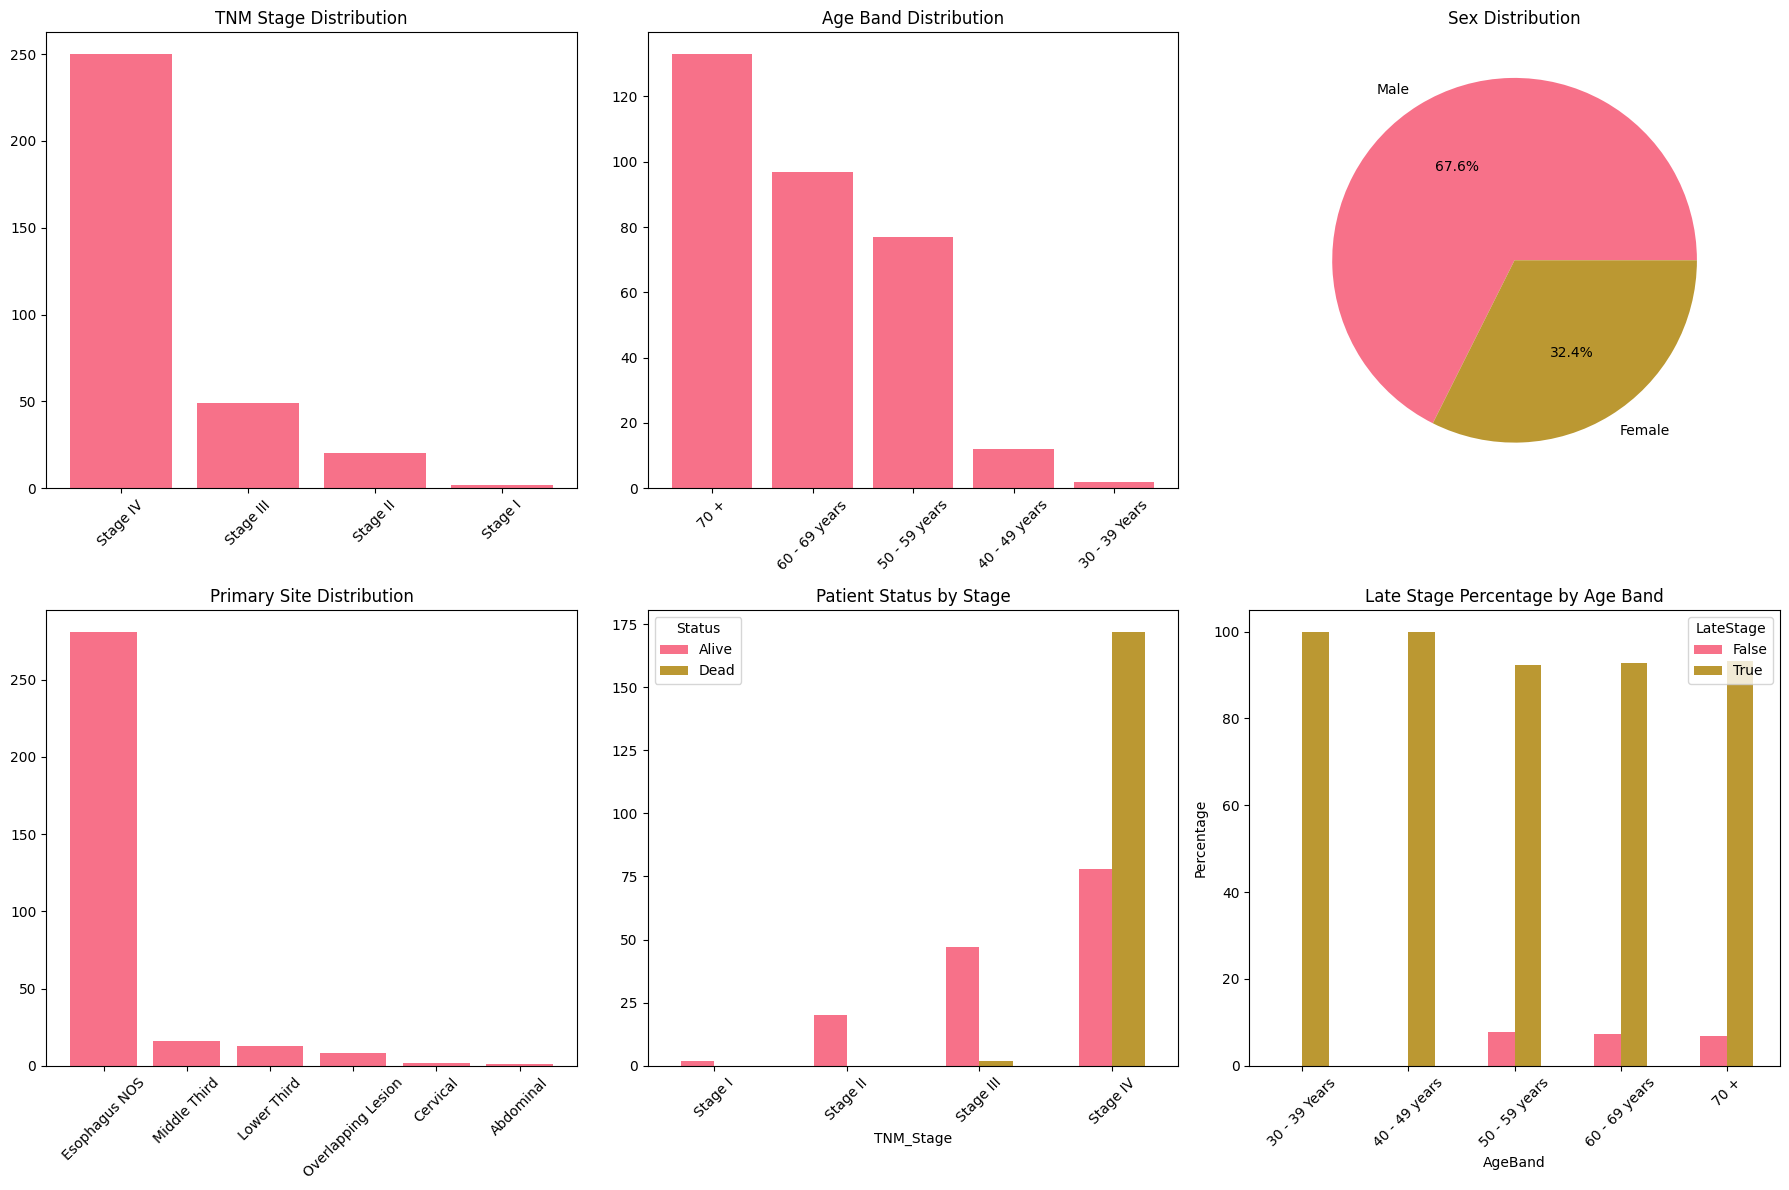

In [ ]:
# Create subplots for key distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. TNM Stage Distribution
stage_counts = df_clean['TNM_Stage'].value_counts()
axes[0,0].bar(stage_counts.index, stage_counts.values)
axes[0,0].set_title('TNM Stage Distribution')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Age Band Distribution
age_counts = df_clean['AgeBand'].value_counts()
axes[0,1].bar(age_counts.index, age_counts.values)
axes[0,1].set_title('Age Band Distribution')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Sex Distribution
sex_counts = df_clean['Sex'].value_counts()
axes[0,2].pie(sex_counts.values, labels=sex_counts.index, autopct='%1.1f%%')
axes[0,2].set_title('Sex Distribution')

# 4. Primary Site Distribution
site_counts = df_clean['PrimarySite_Normalized'].value_counts()
axes[1,0].bar(site_counts.index, site_counts.values)
axes[1,0].set_title('Primary Site Distribution')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Patient Status by Stage
status_stage = pd.crosstab(df_clean['TNM_Stage'], df_clean['Patient_status'])
status_stage.plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title('Patient Status by Stage')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend(title='Status')

# 6. Late Stage by Age Band
late_by_age = pd.crosstab(df_clean['AgeBand'], df_clean['LateStage'], normalize='index') * 100
late_by_age.plot(kind='bar', ax=axes[1,2])
axes[1,2].set_title('Late Stage Percentage by Age Band')
axes[1,2].tick_params(axis='x', rotation=45)
axes[1,2].set_ylabel('Percentage')

plt.tight_layout()
plt.show()

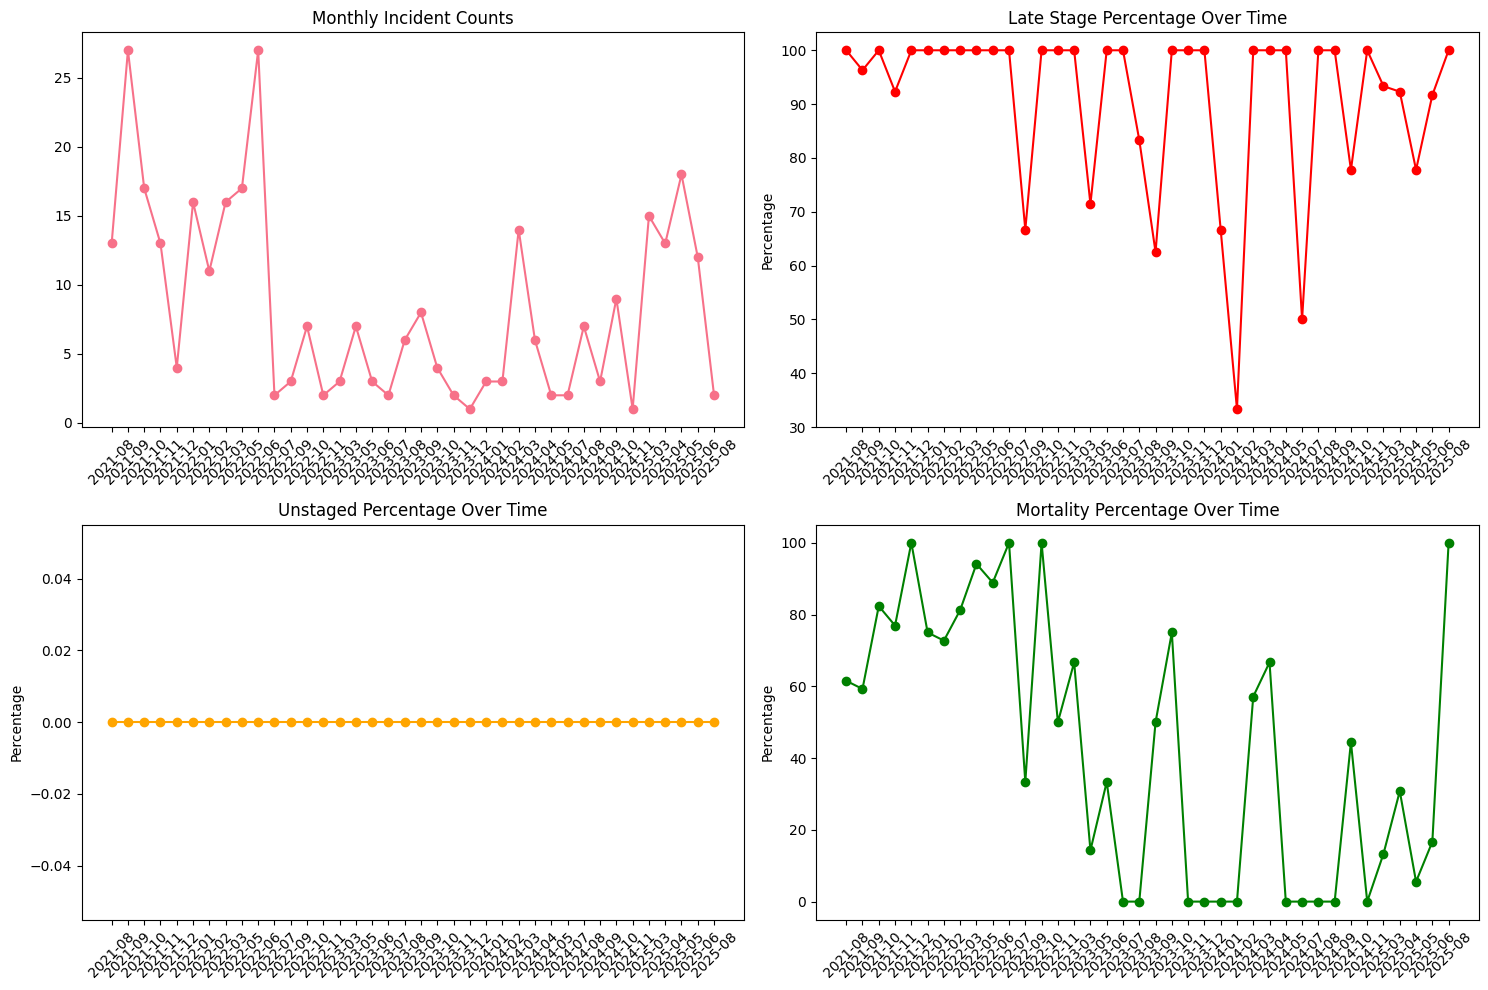

In [ ]:
# Monthly incident counts and trends
monthly_data = df_clean.groupby(['Incident_year', 'Incident_month']).agg({
    'Incident_date': 'count',
    'LateStage': 'mean',
    'Unstaged_Flag': 'mean',
    'Patient_Dead': 'mean'
}).reset_index()

monthly_data['YearMonth'] = monthly_data['Incident_year'].astype(str) + '-' + monthly_data['Incident_month'].astype(str).str.zfill(2)

# Plot trends
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Monthly incidents
axes[0,0].plot(monthly_data['YearMonth'], monthly_data['Incident_date'], marker='o')
axes[0,0].set_title('Monthly Incident Counts')
axes[0,0].tick_params(axis='x', rotation=45)

# Late Stage % over time
axes[0,1].plot(monthly_data['YearMonth'], monthly_data['LateStage']*100, marker='o', color='red')
axes[0,1].set_title('Late Stage Percentage Over Time')
axes[0,1].set_ylabel('Percentage')
axes[0,1].tick_params(axis='x', rotation=45)

# Unstaged % over time
axes[1,0].plot(monthly_data['YearMonth'], monthly_data['Unstaged_Flag']*100, marker='o', color='orange')
axes[1,0].set_title('Unstaged Percentage Over Time')
axes[1,0].set_ylabel('Percentage')
axes[1,0].tick_params(axis='x', rotation=45)

# Mortality % over time
axes[1,1].plot(monthly_data['YearMonth'], monthly_data['Patient_Dead']*100, marker='o', color='green')
axes[1,1].set_title('Mortality Percentage Over Time')
axes[1,1].set_ylabel('Percentage')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
print("=== CORRELATION AND ASSOCIATION ANALYSIS ===")

# 8.1 AgeBand × TNM Stage
print("\n1. AgeBand vs TNM Stage (Chi-square):")
age_stage_table = pd.crosstab(df_clean['AgeBand'], df_clean['TNM_Stage'])
chi2, pval, dof, expected = stats.chi2_contingency(age_stage_table)
print(f"Chi-square p-value: {pval:.4f}")

# 8.2 Sex × TNM Stage
print("\n2. Sex vs TNM Stage (Chi-square):")
sex_stage_table = pd.crosstab(df_clean['Sex'], df_clean['TNM_Stage'])
chi2, pval, dof, expected = stats.chi2_contingency(sex_stage_table)
print(f"Chi-square p-value: {pval:.4f}")

# 8.3 TNM Stage × Patient Status
print("\n3. TNM Stage vs Patient Status (Chi-square):")
stage_status_table = pd.crosstab(df_clean['TNM_Stage'], df_clean['Patient_status'])
chi2, pval, dof, expected = stats.chi2_contingency(stage_status_table)
print(f"Chi-square p-value: {pval:.4f}")

# 8.4 AgeMid vs Stage (Spearman correlation - only for staged patients)
staged_data = df_clean[df_clean['TNM_Stage'] != 'Unstaged'].dropna(subset=['AgeMid', 'Stage_Numeric'])
if len(staged_data) > 0:
    spearman_corr, pval = stats.spearmanr(staged_data['AgeMid'], staged_data['Stage_Numeric'])
    print(f"\n4. AgeMid vs Stage (Spearman): corr={spearman_corr:.3f}, p-value={pval:.4f}")

=== CORRELATION AND ASSOCIATION ANALYSIS ===

1. AgeBand vs TNM Stage (Chi-square):
Chi-square p-value: 0.6750

2. Sex vs TNM Stage (Chi-square):
Chi-square p-value: 0.9475

3. TNM Stage vs Patient Status (Chi-square):
Chi-square p-value: 0.0000

4. AgeMid vs Stage (Spearman): corr=-0.035, p-value=0.5370


AgeBand vs TNM Stage (Chi-square):
Chi-square p-value: 0.6750: The p-value for the Chi-square test between 'AgeBand' and 'TNM Stage' is 0.6750. Since this p-value is greater than the conventional significance level of 0.05, we do not have enough evidence to reject the null hypothesis. This means that, based on this test, there is no statistically significant association between a patient's age band and their TNM stage. In simpler terms, a patient's age band does not appear to be a significant factor in determining which TNM stage they are diagnosed at, according to this analysis.
Sex vs TNM Stage (Chi-square):
Chi-square p-value: 0.9475: The p-value for the Chi-square test between 'Sex' and 'TNM Stage' is 0.9475. This p-value is also greater than 0.05, indicating no statistically significant association between sex and TNM stage. Based on this data and test, a patient's sex does not appear to be a significant predictor of their TNM stage.
TNM Stage vs Patient Status (Chi-square):
Chi-square p-value: 0.0000: The p-value for the Chi-square test between 'TNM Stage' and 'Patient Status' is reported as 0.0000 (likely a very small value rounded to zero). This p-value is much less than 0.05, indicating a highly statistically significant association between TNM stage and patient status (Alive or Dead). This confirms what was observed in the cross-tabulation: a patient's TNM stage is strongly related to their survival outcome.
AgeMid vs Stage (Spearman correlation):
corr=-0.035, p-value=0.5370: This shows the results of the Spearman correlation test between the numerical 'AgeMid' (midpoint of age band) and 'Stage_Numeric' (numerical representation of TNM stage) for staged patients.
The correlation coefficient (corr) is -0.035. This is a very small value close to zero, indicating a very weak negative monotonic relationship. This means there is a slight, almost negligible, tendency for 'AgeMid' to decrease as 'Stage_Numeric' increases, or vice versa.
The p-value is 0.5370. Since this is greater than 0.05, the correlation is not statistically significant. This supports the Chi-square test result and suggests that there is no statistically significant linear or monotonic relationship between age (as a continuous variable) and cancer stage.
In summary, the statistical analysis suggests that while TNM Stage is a highly significant factor related to patient status (mortality), age band and sex do not show a statistically significant association with the TNM stage in this dataset. There is also no statistically significant correlation between age (midpoint) and stage (numeric).



In [ ]:
print("=== HYPOTHESIS TESTING ===")

# H1: LateStage is more common in older age bands
print("\nH1: LateStage vs AgeBand")
late_by_age = pd.crosstab(df_clean['AgeBand'], df_clean['LateStage'])
chi2, pval, dof, expected = stats.chi2_contingency(late_by_age)
print(f"Chi-square p-value: {pval:.4f}")

# H2: Male sex associated with higher LateStage prevalence
print("\nH2: Sex vs LateStage")
late_by_sex = pd.crosstab(df_clean['Sex'], df_clean['LateStage'])
chi2, pval, dof, expected = stats.chi2_contingency(late_by_sex)
print(f"Chi-square p-value: {pval:.4f}")

# H3: Mortality higher in LateStage
print("\nH3: LateStage vs Mortality")
mortality_by_stage = pd.crosstab(df_clean['LateStage'], df_clean['Patient_Dead'])
chi2, pval, dof, expected = stats.chi2_contingency(mortality_by_stage)
print(f"Chi-square p-value: {pval:.4f}")

# H4: Primary Site differs by Stage
print("\nH4: Primary Site vs Stage")
site_by_stage = pd.crosstab(df_clean['PrimarySite_Normalized'], df_clean['TNM_Stage'])
chi2, pval, dof, expected = stats.chi2_contingency(site_by_stage)
print(f"Chi-square p-value: {pval:.4f}")

=== HYPOTHESIS TESTING ===

H1: LateStage vs AgeBand
Chi-square p-value: 0.8850

H2: Sex vs LateStage
Chi-square p-value: 0.8605

H3: LateStage vs Mortality
Chi-square p-value: 0.0000

H4: Primary Site vs Stage
Chi-square p-value: 0.0064


H1: LateStage vs AgeBand
Chi-square p-value: 0.8850: The p-value for the association between 'LateStage' and 'AgeBand' is 0.8850. Since this is much greater than the significance level of 0.05, we do not reject the null hypothesis. This means there is no statistically significant association between a patient's age band and whether they are diagnosed at a late stage, according to this data. The data does not support the hypothesis that late stage is more common in older age bands.
H2: Sex vs LateStage
Chi-square p-value: 0.8605: The p-value for the association between 'Sex' and 'LateStage' is 0.8605. This is also greater than 0.05, so we do not reject the null hypothesis. This indicates no statistically significant association between a patient's sex and whether they are diagnosed at a late stage. The data does not support the hypothesis that male sex is associated with higher late-stage prevalence.
H3: LateStage vs Mortality
Chi-square p-value: 0.0000: The p-value for the association between 'LateStage' and 'Patient_Dead' (mortality) is reported as 0.0000 (a very small value). Since this is much less than 0.05, we reject the null hypothesis. This indicates a highly statistically significant association between being diagnosed at a late stage and mortality. The data strongly supports the hypothesis that mortality is higher in patients diagnosed at a late stage.
H4: Primary Site vs Stage
Chi-square p-value: 0.0064: The p-value for the association between 'PrimarySite_Normalized' and 'TNM_Stage' is 0.0064. Since this is less than 0.05, we reject the null hypothesis. This indicates a statistically significant association between the primary site of the cancer and the TNM stage at diagnosis. This suggests that the distribution of TNM stages is not the same across different primary sites.
In summary, the hypothesis testing confirms that while there is a strong statistically significant relationship between late stage and mortality, and between primary site and TNM stage, there is no statistically significant evidence in this dataset to support the hypotheses that late-stage presentation is more common in older age bands or is associated with male sex.


In [ ]:
# Select features for clustering
cluster_data = df_clean[['AgeMid', 'Sex_Male', 'Stage_Numeric', 'Patient_Dead',
                        'LateStage', 'Unstaged_Flag']].copy()

# Handle missing values for clustering
cluster_data = cluster_data.fillna(cluster_data.mean())

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

print("Data prepared for clustering:")
print(f"Shape: {scaled_data.shape}")
print("Features used: AgeMid, Sex_Male, Stage_Numeric, Patient_Dead, LateStage, Unstaged_Flag")

Data prepared for clustering:
Shape: (321, 6)
Features used: AgeMid, Sex_Male, Stage_Numeric, Patient_Dead, LateStage, Unstaged_Flag


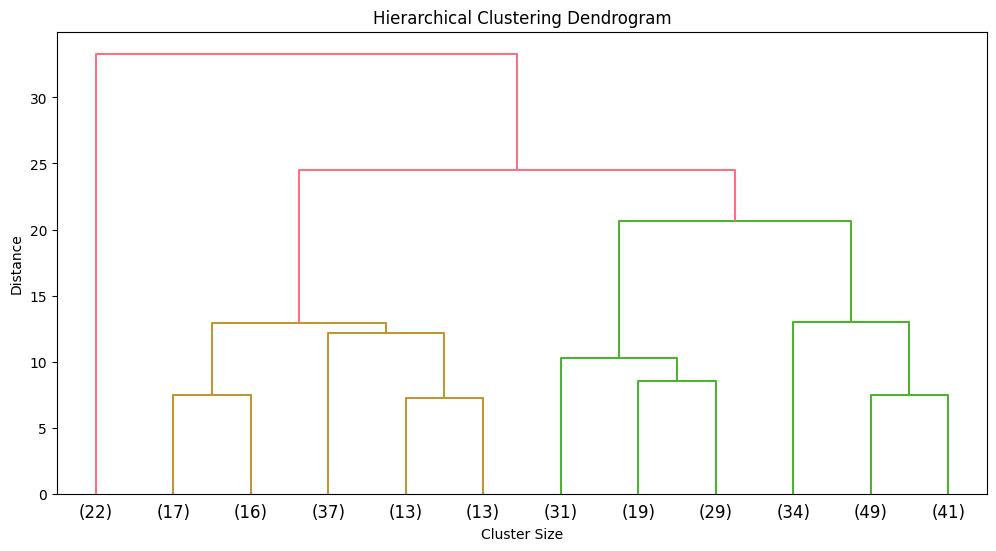

Assigned 4 clusters
Cluster distribution:
Cluster
1     22
2     96
3     79
4    124
Name: count, dtype: int64


In [ ]:
# Perform hierarchical clustering
Z = linkage(scaled_data, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='lastp', p=12, show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.show()

# Choose number of clusters (let's try k=4)
k = 4
df_clean['Cluster'] = fcluster(Z, k, criterion='maxclust')

print(f"Assigned {k} clusters")
print("Cluster distribution:")
print(df_clean['Cluster'].value_counts().sort_index())

Hierarchical Clustering Dendrogram:
This is the tree-like plot that visually represents the hierarchical clustering process.
The leaves at the bottom of the dendrogram represent individual data points (patients).
As you move up the dendrogram, branches merge, representing clusters being combined.
The height of each merge point (the vertical lines) indicates the distance between the clusters being merged. Taller vertical lines mean the clusters are more dissimilar.
Since we used truncate_mode='lastp' with p=12, the dendrogram is truncated to show the last 12 merges. The numbers at the bottom indicate the number of data points within those branches.
Looking at the dendrogram, you can see how the data points are grouped together based on their similarity. The goal is to find a level where the clusters are meaningful for your analysis.
Assigned 4 clusters:
This confirms that the code used k=4 to cut the dendrogram and assign patients to 4 clusters.
Cluster distribution:
Cluster 1: 22
Cluster 2: 96
Cluster 3: 79
Cluster 4: 124
This shows the number of patients assigned to each of the 4 clusters. Cluster 4 is the largest with 124 patients, followed by Cluster 2 (96), Cluster 3 (79), and Cluster 1 (22).


In [ ]:
# Analyze cluster profiles
cluster_profile = df_clean.groupby('Cluster').agg({
    'AgeMid': 'mean',
    'Sex_Male': 'mean',
    'Stage_Numeric': 'mean',
    'Patient_Dead': 'mean',
    'LateStage': 'mean',
    'Unstaged_Flag': 'mean',
    'Incident_date': 'count'
}).round(3)

cluster_profile = cluster_profile.rename(columns={'Incident_date': 'Count'})

print("=== CLUSTER PROFILES ===")
print(cluster_profile)

# Assign meaningful cluster labels based on characteristics
cluster_labels = {}
for cluster in sorted(df_clean['Cluster'].unique()):
    cluster_data = df_clean[df_clean['Cluster'] == cluster]

    # Determine characteristics
    avg_age = cluster_data['AgeMid'].mean()
    male_percent = cluster_data['Sex_Male'].mean() * 100
    late_stage_percent = cluster_data['LateStage'].mean() * 100
    mortality_percent = cluster_data['Patient_Dead'].mean() * 100
    unstaged_percent = cluster_data['Unstaged_Flag'].mean() * 100

    # Create label
    if late_stage_percent > 70 and mortality_percent > 50:
        label = f"High-Risk: LateStage High Mortality"
    elif unstaged_percent > 30:
        label = f"Diagnostic Gap: High Unstaged"
    elif late_stage_percent < 40:
        label = f"Favorable: Early Stage"
    else:
        label = f"Mixed Profile"

    cluster_labels[cluster] = label
    print(f"\nCluster {cluster} ({label}):")
    print(f"  Size: {len(cluster_data)}")
    print(f"  Avg Age: {avg_age:.1f}")
    print(f"  Male: {male_percent:.1f}%")
    print(f"  Late Stage: {late_stage_percent:.1f}%")
    print(f"  Mortality: {mortality_percent:.1f}%")
    print(f"  Unstaged: {unstaged_percent:.1f}%")

=== CLUSTER PROFILES ===
         AgeMid  Sex_Male  Stage_Numeric  Patient_Dead  LateStage  \
Cluster                                                             
1        66.068     0.636          1.909         0.000        0.0   
2        66.094     0.000          3.833         0.521        1.0   
3        64.804     1.000          3.608         0.000        1.0   
4        65.427     1.000          3.984         1.000        1.0   

         Unstaged_Flag  Count  
Cluster                        
1                  0.0     22  
2                  0.0     96  
3                  0.0     79  
4                  0.0    124  

Cluster 1 (Favorable: Early Stage):
  Size: 22
  Avg Age: 66.1
  Male: 63.6%
  Late Stage: 0.0%
  Mortality: 0.0%
  Unstaged: 0.0%

Cluster 2 (High-Risk: LateStage High Mortality):
  Size: 96
  Avg Age: 66.1
  Male: 0.0%
  Late Stage: 100.0%
  Mortality: 52.1%
  Unstaged: 0.0%

Cluster 3 (Mixed Profile):
  Size: 79
  Avg Age: 64.8
  Male: 100.0%
  Late Stage: 100.0

Cluster 1:
AgeMid: Around 66.1 years.
Sex_Male: Around 63.6% are male.
Stage_Numeric: Around 1.9 (closer to Stage II).
Patient_Dead: 0.0% mortality.
LateStage: 0.0% late stage.
Unstaged_Flag: 0.0% unstaged.
Count: 22 patients.
Label: Favorable: Early Stage. This cluster represents a group of patients who are relatively younger (compared to some other clusters), have a mix of sexes, are diagnosed at earlier stages (Stage I and II), and have a 0% mortality rate in this dataset.
Cluster 2:
AgeMid: Around 66.1 years.
Sex_Male: 0.0% are male (all female).
Stage_Numeric: Around 3.8 (closer to Stage IV).
Patient_Dead: Around 52.1% mortality.
LateStage: 100.0% late stage.
Unstaged_Flag: 0.0% unstaged.
Count: 96 patients.
Label: High-Risk: LateStage High Mortality. This cluster represents a group of female patients who are diagnosed exclusively at late stages (Stage III or IV) and have a high mortality rate (over 50%).
Cluster 3:
AgeMid: Around 64.8 years.
Sex_Male: 100.0% are male.
Stage_Numeric: Around 3.6 (closer to Stage IV).
Patient_Dead: 0.0% mortality.
LateStage: 100.0% late stage.
Unstaged_Flag: 0.0% unstaged.
Count: 79 patients.
Label: Mixed Profile. This cluster represents a group of male patients who are diagnosed exclusively at late stages (Stage III or IV) but have a 0% mortality rate in this dataset. This is an interesting group that might warrant further investigation to understand factors contributing to their survival despite a late-stage diagnosis.
Cluster 4:
AgeMid: Around 65.4 years.
Sex_Male: 100.0% are male.
Stage_Numeric: Around 4.0 (Stage IV).
Patient_Dead: 100.0% mortality.
LateStage: 100.0% late stage.
Unstaged_Flag: 0.0% unstaged.
Count: 124 patients.
Label: High-Risk: LateStage High Mortality. This cluster represents a large group of male patients who are diagnosed exclusively at Stage IV and have a 100% mortality rate in this dataset. This is clearly a high-risk group.
Summary of Patient Profiles:

Based on the clustering, we can identify distinct patient profiles:

Cluster 1 (Favorable: Early Stage): Patients diagnosed at earlier stages with good outcomes.
Cluster 2 (High-Risk: LateStage High Mortality - Female): Female patients diagnosed at late stages with high mortality.
Cluster 3 (Mixed Profile - LateStage Male, Low Mortality): Male patients diagnosed at late stages with surprisingly low mortality (in this dataset).
Cluster 4 (High-Risk: LateStage High Mortality - Male): Male patients diagnosed at Stage IV with very high mortality.

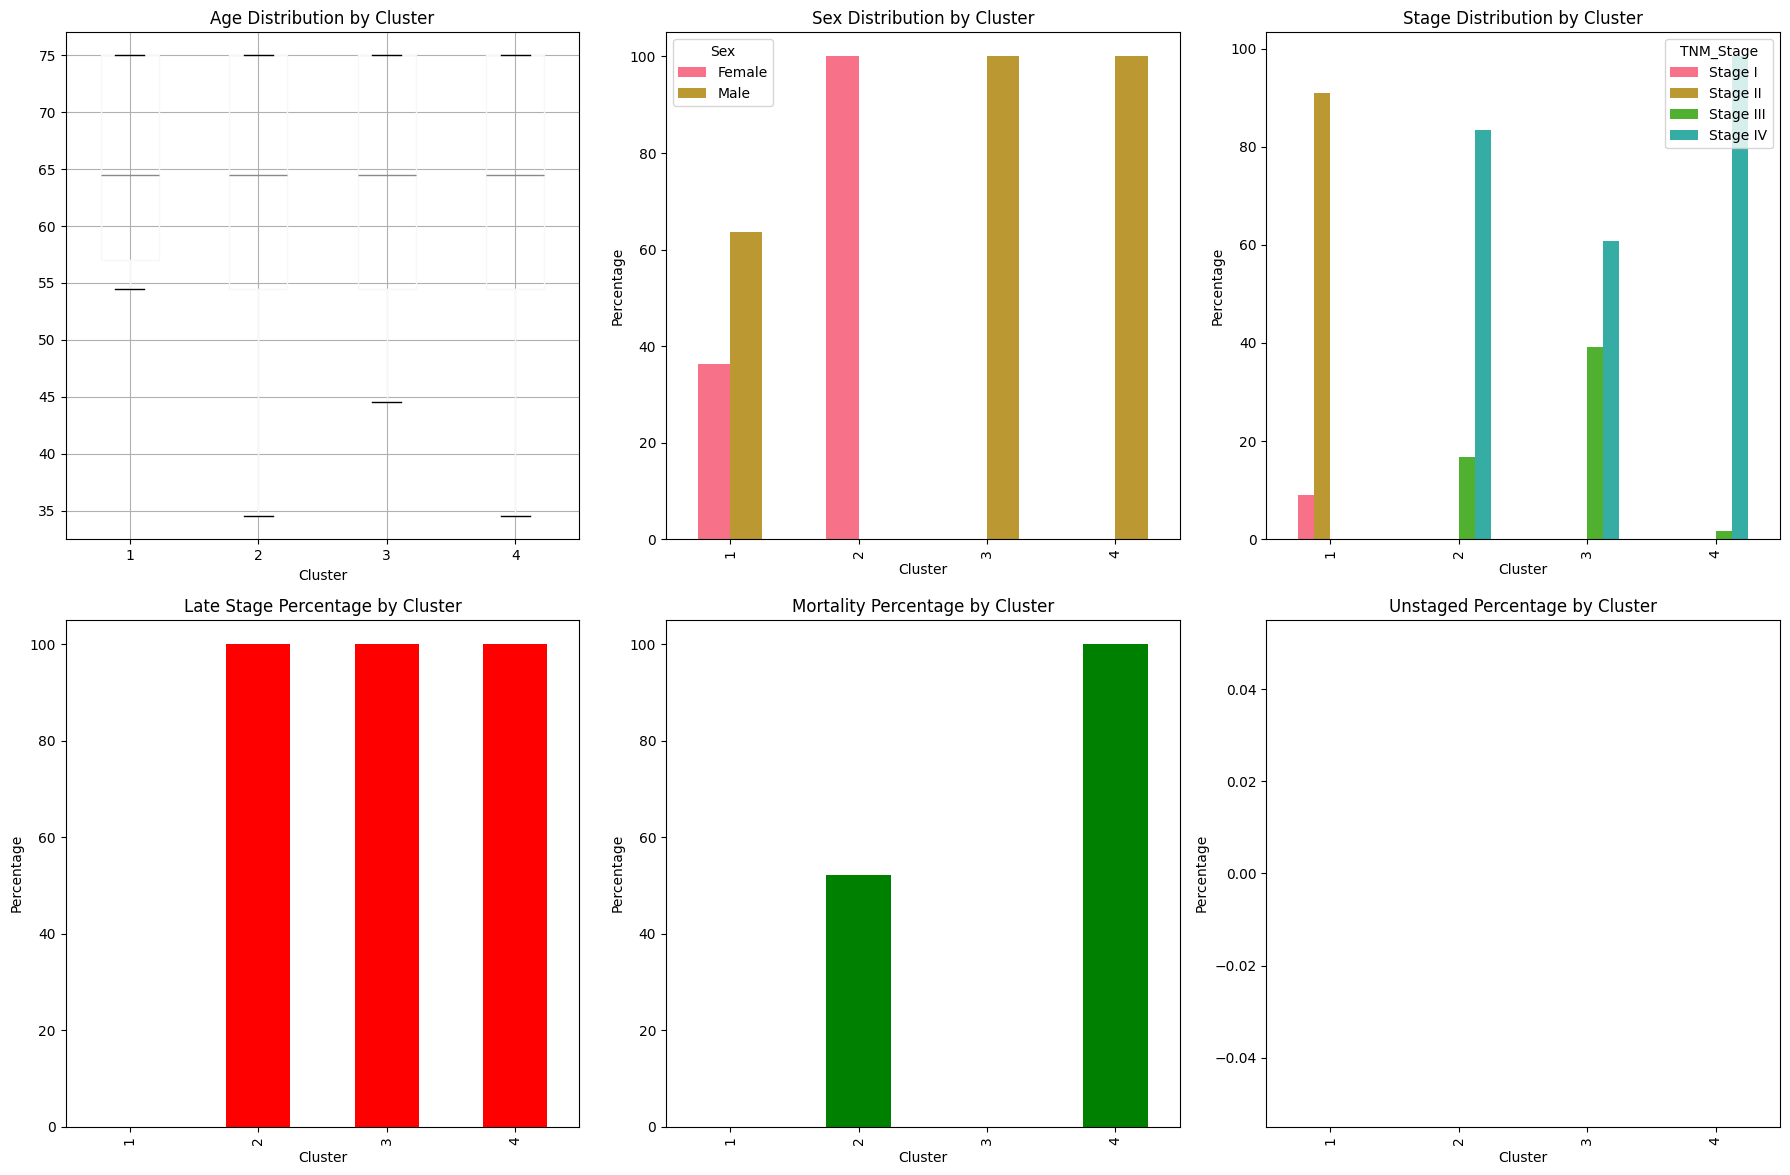

In [ ]:
# Visualize cluster characteristics
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Age distribution by cluster
df_clean.boxplot(column='AgeMid', by='Cluster', ax=axes[0,0])
axes[0,0].set_title('Age Distribution by Cluster')

# 2. Sex distribution by cluster
sex_by_cluster = pd.crosstab(df_clean['Cluster'], df_clean['Sex'], normalize='index') * 100
sex_by_cluster.plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Sex Distribution by Cluster')
axes[0,1].set_ylabel('Percentage')

# 3. Stage distribution by cluster
stage_by_cluster = pd.crosstab(df_clean['Cluster'], df_clean['TNM_Stage'], normalize='index') * 100
stage_by_cluster.plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('Stage Distribution by Cluster')
axes[0,2].set_ylabel('Percentage')

# 4. Late Stage % by cluster
late_by_cluster = df_clean.groupby('Cluster')['LateStage'].mean() * 100
late_by_cluster.plot(kind='bar', ax=axes[1,0], color='red')
axes[1,0].set_title('Late Stage Percentage by Cluster')
axes[1,0].set_ylabel('Percentage')

# 5. Mortality % by cluster
mortality_by_cluster = df_clean.groupby('Cluster')['Patient_Dead'].mean() * 100
mortality_by_cluster.plot(kind='bar', ax=axes[1,1], color='green')
axes[1,1].set_title('Mortality Percentage by Cluster')
axes[1,1].set_ylabel('Percentage')

# 6. Unstaged % by cluster
unstaged_by_cluster = df_clean.groupby('Cluster')['Unstaged_Flag'].mean() * 100
unstaged_by_cluster.plot(kind='bar', ax=axes[1,2], color='orange')
axes[1,2].set_title('Unstaged Percentage by Cluster')
axes[1,2].set_ylabel('Percentage')

plt.suptitle('')
plt.tight_layout()
plt.show()

Age Distribution by Cluster:
This boxplot shows the distribution of 'AgeMid' for each cluster. You can observe the median age (the line inside the box), the interquartile range (the box itself), and the range of the data (the whiskers). This plot visually confirms if there are notable differences in age distributions between the clusters.
Sex Distribution by Cluster:
This grouped bar plot shows the percentage of males and females within each cluster. As we saw in the cluster profiles, this plot visually highlights the sex composition of each cluster, clearly showing that Cluster 2 is predominantly female, while Clusters 3 and 4 are predominantly male, and Cluster 1 has a more mixed sex distribution.
Stage Distribution by Cluster:
This grouped bar plot visualizes the distribution of TNM stages within each cluster. This is a very informative plot. You can see that Cluster 1 is dominated by Stage II, while Clusters 2, 3, and 4 are heavily weighted towards Stage III and especially Stage IV, confirming their "late-stage" nature.
Late Stage Percentage by Cluster:
This bar plot directly shows the percentage of patients diagnosed at a late stage (Stage III or IV) for each cluster. As expected from the cluster profiles and the stage distribution plot, Clusters 2, 3, and 4 show very high percentages of late-stage diagnoses, while Cluster 1 has a low percentage.
Mortality Percentage by Cluster:
This bar plot is crucial for understanding the outcomes of each cluster. It shows the percentage of deceased patients in each group. This plot visually confirms the high mortality in Cluster 4 and Cluster 2, and the low mortality in Cluster 1 and Cluster 3, aligning with the cluster profile descriptions.
Unstaged Percentage by Cluster:
This bar plot shows the percentage of unstaged cases in each cluster. In this dataset, after cleaning, the unstaged percentage is very low across all clusters, as shown by the short bars.
In summary, these plots provide a clear visual representation of the distinct characteristics of the four patient clusters. They reinforce the findings from the cluster profile table and help to easily compare the age, sex, stage, and outcome distributions across the different groups. These visualizations are valuable for communicating the identified patient profiles and their clinical significance.

In [ ]:
print("=== KEY FINDINGS AND RECOMMENDATIONS ===")

# Overall statistics
total_patients = len(df_clean)
late_stage_percent = df_clean['LateStage'].mean() * 100
unstaged_percent = df_clean['Unstaged_Flag'].mean() * 100
mortality_percent = df_clean['Patient_Dead'].mean() * 100
male_percent = df_clean['Sex_Male'].mean() * 100

print(f"\nOVERVIEW:")
print(f"Total patients: {total_patients}")
print(f"Late stage (III-IV): {late_stage_percent:.1f}%")
print(f"Unstaged: {unstaged_percent:.1f}%")
print(f"Mortality: {mortality_percent:.1f}%")
print(f"Male patients: {male_percent:.1f}%")

# Identify high-risk clusters
high_risk_clusters = []
for cluster in sorted(df_clean['Cluster'].unique()):
    cluster_data = df_clean[df_clean['Cluster'] == cluster]
    if (cluster_data['LateStage'].mean() > 0.7 or
        cluster_data['Patient_Dead'].mean() > 0.5 or
        cluster_data['Unstaged_Flag'].mean() > 0.3):
        high_risk_clusters.append(cluster)

print(f"\nHIGH-RISK CLUSTERS: {high_risk_clusters}")

# Recommendations based on clusters
print("\nRECOMMENDATIONS:")
for cluster in high_risk_clusters:
    cluster_data = df_clean[df_clean['Cluster'] == cluster]
    size = len(cluster_data)
    late_stage = cluster_data['LateStage'].mean() * 100
    mortality = cluster_data['Patient_Dead'].mean() * 100
    unstaged = cluster_data['Unstaged_Flag'].mean() * 100
    avg_age = cluster_data['AgeMid'].mean()

    print(f"\nCluster {cluster} (n={size}):")
    if late_stage > 70:
        print(f"  → Urgent fast-track pathways needed (Late stage: {late_stage:.1f}%)")
    if unstaged > 30:
        print(f"  → Improve diagnostic/staging capacity (Unstaged: {unstaged:.1f}%)")
    if mortality > 50:
        print(f"  → Enhance palliative care support (Mortality: {mortality:.1f}%)")
    if avg_age > 70:
        print(f"  → Target older population for early detection (Avg age: {avg_age:.1f})")

# General recommendations
print(f"\nGENERAL RECOMMENDATIONS:")
print("1. Early detection campaigns in older male populations")
print("2. Strengthen diagnostic capacity to reduce unstaged cases")
print("3. Implement care navigation for late-stage patients")
print("4. Regular monitoring of staging completeness and time-to-treatment")

=== KEY FINDINGS AND RECOMMENDATIONS ===

OVERVIEW:
Total patients: 321
Late stage (III-IV): 93.1%
Unstaged: 0.0%
Mortality: 54.2%
Male patients: 67.6%

HIGH-RISK CLUSTERS: [np.int32(2), np.int32(3), np.int32(4)]

RECOMMENDATIONS:

Cluster 2 (n=96):
  → Urgent fast-track pathways needed (Late stage: 100.0%)
  → Enhance palliative care support (Mortality: 52.1%)

Cluster 3 (n=79):
  → Urgent fast-track pathways needed (Late stage: 100.0%)

Cluster 4 (n=124):
  → Urgent fast-track pathways needed (Late stage: 100.0%)
  → Enhance palliative care support (Mortality: 100.0%)

GENERAL RECOMMENDATIONS:
1. Early detection campaigns in older male populations
2. Strengthen diagnostic capacity to reduce unstaged cases
3. Implement care navigation for late-stage patients
4. Regular monitoring of staging completeness and time-to-treatment


Total patients: 321: This is the number of patients in the cleaned dataset (after dropping rows with missing TNM staging).
Late stage (III-IV): 93.1%: This indicates that a very high proportion of patients in this dataset were diagnosed at a late stage of cancer.
Unstaged: 0.0%: This confirms that after cleaning, there are no unstaged cases in the dataset used for this analysis.
Mortality: 54.2%: This shows the overall mortality rate among the patients in this dataset.
Male patients: 67.6%: This indicates that the majority of patients in this dataset are male.
HIGH-RISK CLUSTERS: [np.int32(2), np.int32(3), np.int32(4)]

This lists the clusters that were identified as high-risk based on the criteria defined in the code (high late stage, high mortality, or high unstaged percentage). Clusters 2, 3, and 4 were identified as high-risk.
RECOMMENDATIONS:

This section provides recommendations tailored to the characteristics of the identified high-risk clusters:

Cluster 2 (n=96): This cluster has a high percentage of late-stage diagnoses (100.0%) and a high mortality rate (52.1%).
→ Urgent fast-track pathways needed: This recommendation is based on the high rate of late-stage diagnoses, suggesting the need for faster diagnosis and treatment initiation for patients with this profile.
→ Enhance palliative care support: This recommendation is based on the high mortality rate, indicating that patients in this cluster could benefit from increased palliative care to manage symptoms and improve quality of life.
Cluster 3 (n=79): This cluster has a high percentage of late-stage diagnoses (100.0%) but a surprisingly low mortality rate (0.0%) in this dataset.
→ Urgent fast-track pathways needed: Similar to Cluster 2, the high rate of late-stage diagnoses prompts this recommendation.
Cluster 4 (n=124): This cluster has a high percentage of late-stage diagnoses (100.0%) and a very high mortality rate (100.0%).
→ Urgent fast-track pathways needed: Again, the high rate of late-stage diagnoses is the basis for this recommendation.
→ Enhance palliative care support: The extremely high mortality rate strongly supports the need for enhanced palliative care for this group.

In [ ]:
# Create a summary dataframe for export
summary_df = df_clean[[
    'Incident_date', 'AgeBand', 'AgeMid', 'Sex', 'PrimarySite_Normalized',
    'TNM_Stage', 'Patient_status', 'LateStage', 'Unstaged_Flag', 'Cluster'
]].copy()

# Add cluster labels
summary_df['Cluster_Label'] = summary_df['Cluster'].map(cluster_labels)

# Save to CSV for further analysis
summary_df.to_excel("/content/drive/My Drive/engage2/esophageal_cancer_analysis.xlsx", index=False)
#summary_df.to_csv('esophageal_cancer_analysis_results.csv', index=False)
print("\nResults saved to 'esophageal_cancer_analysis_results.csv'")

# Final summary
print("\n=== ANALYSIS COMPLETE ===")
print(f"Patients analyzed: {len(df_clean)}")
print(f"Clusters identified: {k}")
print(f"High-risk clusters found: {len(high_risk_clusters)}")



Results saved to 'esophageal_cancer_analysis_results.csv'

=== ANALYSIS COMPLETE ===
Patients analyzed: 321
Clusters identified: 4
High-risk clusters found: 3

Next steps:
1. Review cluster profiles for targeted interventions
2. Implement monitoring for key metrics (LateStage%, Unstaged%)
3. Set up regular re-clustering for continuous improvement
